# pdfplumber vs LightOnOCR-2-1B — gemma4:e4b only

Two ways of reading the PDF, compared for one model (gemma4:e4b): pdfplumber (reads text
and fonts) vs LightOnOCR (reads the page as an image). Both are scored the same way,
and only the final, fixed-up output is compared here.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    LABELS, _confusion_from_match, _match_structured, compute_f1_rows,
    extract_gold, micro_prf1,
)
from dmpbridge.evaluation.annotation_rules import resolve_new_gt_path

MODEL = 'gemma4:e4b'
SAMPLES = range(1, 11)
TAGS = {
    'pdfplumber':  P.make_tag(MODEL, 'pdfplumber'),
    'LightOnOCR':  'gemma4-e4b_lightonocr_whole_doc',
}

COLOURS = {'pdfplumber': '#2a78d6', 'LightOnOCR': '#eb6834'}
INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})
pd.set_option('display.max_colwidth', 60)

CONF, available = {}, []
for name, tag in TAGS.items():
    if not all(P.final_path(tag, n).exists() for n in SAMPLES):
        print(f'not available (missing final output), skipped: {name}')
        continue
    conf = {}
    for lbl, val in [(l, l) for l in LABELS]:
        pass
    from collections import defaultdict
    pooled = defaultdict(lambda: defaultdict(int))
    for n in SAMPLES:
        gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
        records, no_gold = _match_structured(P.final_path(tag, n), gold,
                                             dedup_question_title=False)
        this = _confusion_from_match(records, no_gold)
        for k, row in this.items():
            for kk, v in row.items():
                pooled[k][kk] += v
    CONF[name] = pooled
    available.append(name)

print('comparing:', ', '.join(available))


comparing: pdfplumber, LightOnOCR


## 1. Headline

Same metrics as every other results notebook: precision, recall, and f1-score, pooled
across all 10 documents.


In [2]:
rows = []
for name in available:
    m = micro_prf1(CONF[name])
    rows.append({'extractor': name, 'precision': m['precision'], 'recall': m['recall'],
                 'f1': m['f1'], 'TP': m['tp'], 'FP': m['fp'], 'FN': m['fn']})
head = pd.DataFrame(rows).set_index('extractor')
display(head.style.background_gradient(cmap='Greens', subset=['f1'])
        .format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'}))


,precision,recall,f1,TP,FP,FN
extractor,,,,,,
pdfplumber,0.959,0.943,0.951,164,7,10
LightOnOCR,0.844,0.810,0.827,141,26,33


## 2. Per-class f1-score


,support,pdfplumber,LightOnOCR
label,,,
title,10,1.000,0.947
section.title,45,1.000,0.946
section.description,8,0.889,0.571
question.text,56,0.927,0.812
answer.text,55,0.935,0.780


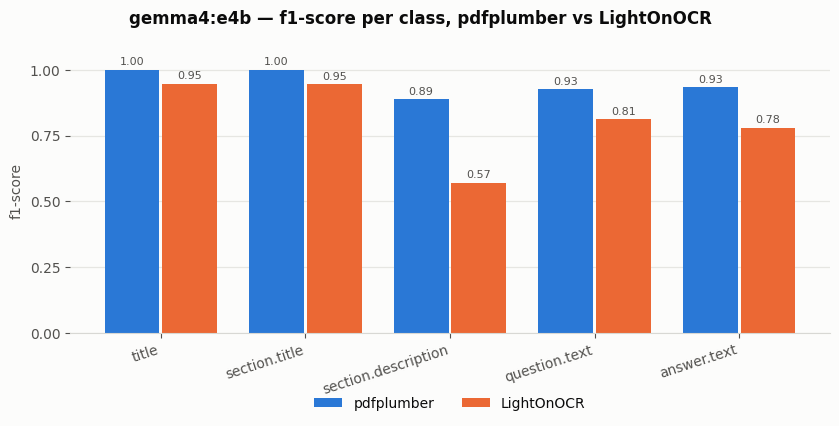

In [3]:
per = {name: compute_f1_rows(CONF[name]).set_index('label') for name in available}
tbl = pd.DataFrame({name: per[name]['f1'] for name in available})
tbl.insert(0, 'support', per[available[0]]['support'].astype(int))
display(tbl.style.background_gradient(cmap='Greens', subset=available, axis=None)
        .format({name: '{:.3f}' for name in available} | {'support': '{:.0f}'}))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(LABELS))
w = 0.8 / max(len(available), 1)
for k, name in enumerate(available):
    vals = [per[name]['f1'].get(l, 0) for l in LABELS]
    bars = ax.bar(x + (k - (len(available) - 1) / 2) * w, vals,
                  width=w - 0.02, color=COLOURS[name], label=name)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8, color=MUTED)
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=18, ha='right')
ax.set_ylim(0, 1.08); ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel('f1-score')
ax.grid(axis='y', color=GRID, linewidth=0.9); ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.legend(ncol=len(available), loc='upper center', bbox_to_anchor=(0.5, -0.18))
fig.suptitle(f'{MODEL} — f1-score per class, pdfplumber vs LightOnOCR', fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Per-sample — where the two extractors disagree

One overall score can hide a lot. This breaks it down document by document.


In [4]:
def sample_f1(name, n):
    tag = TAGS[name]
    gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
    records, no_gold = _match_structured(P.final_path(tag, n), gold,
                                         dedup_question_title=False)
    tp = sum(1 for r in records if r['pred_text'] and r['pred_label'] == r['gold_label'])
    fp = len(no_gold)
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / len(records) if records else 0
    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0

rows = [{'sample': n, **{name: sample_f1(name, n) for name in available}} for n in SAMPLES]
df = pd.DataFrame(rows).set_index('sample')
if len(available) == 2:
    a, b = available
    df['difference'] = df[b] - df[a]
display(df.style.background_gradient(cmap='RdYlGn', subset=available, vmin=0, vmax=1)
        .format('{:.3f}'))


,pdfplumber,LightOnOCR,difference
sample,,,
1,1.000,1.000,0.000
2,0.800,0.609,-0.191
3,1.000,0.944,-0.056
4,1.000,1.000,0.000
5,0.865,0.538,-0.326
6,1.000,1.000,0.000
7,1.000,1.000,0.000
8,1.000,0.722,-0.278
9,1.000,1.000,0.000


## 4. Sample6 — the reason this comparison exists

Sample6's headings are underlined, not bold. pdfplumber needed a special fix to see
that. LightOnOCR reads the page as an image, so it can see an underline the way a
person would — this checks whether it actually does.


In [5]:
for name in available:
    f1 = sample_f1(name, 6)
    print(f'{name:<12} sample6 f1 = {f1:.3f}')


pdfplumber   sample6 f1 = 1.000
LightOnOCR   sample6 f1 = 1.000


Both extractors get this document right — but by different routes. pdfplumber uses its
explicit underline fix; LightOnOCR marked the headings **bold** instead of underlined,
but that was still enough for the model to recognize them as headings.
